In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Shape: (891, 12)

First 10 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            Mc

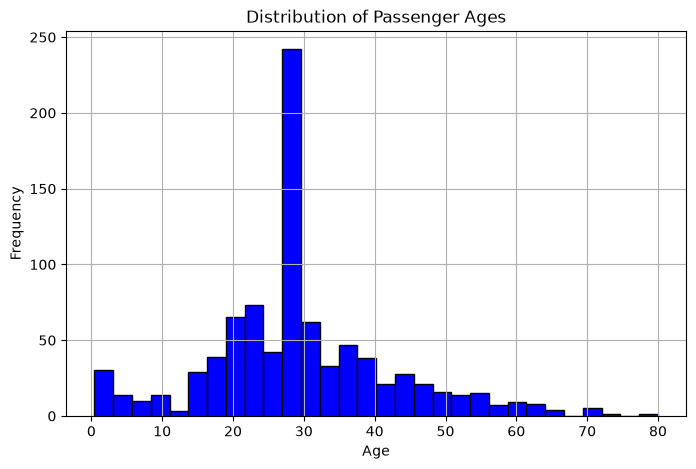

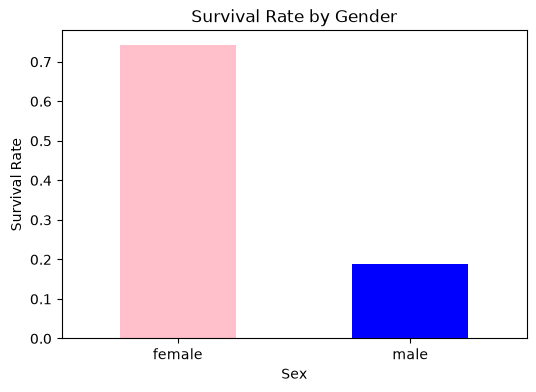

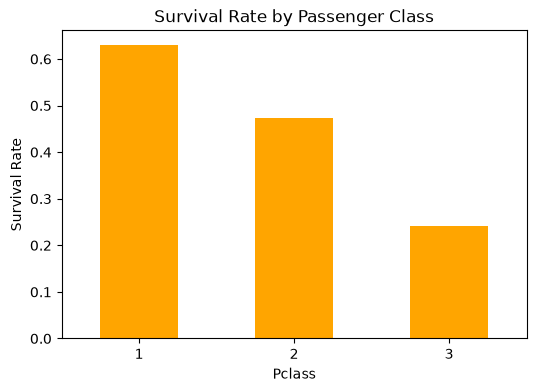

In [2]:
# =======================================================================================================
# Step 1: Load the data
# =======================================================================================================

df = pd.read_csv("Titanic-Dataset.csv")
# Shape
print("Shape:", df.shape)
# 1st 10 rows
print("\nFirst 10 rows:")
print(df.head(10))

# Column Information
print("\nColumn Information")
print(df.info())

# Missing Values per column
print("\nMissing Values per Column:")
print(df.isnull().sum())


# ======================================================================================================
# Step 2: Cleaning
# ======================================================================================================

# Drop duplicate rows
df = df.drop_duplicates()

# Handle Missing Values
# Drop the rows in which row has too many missing values
df = df.dropna(thresh = len(df.columns) -2)

# Fill numerical columns with median and categorial columns with mode
for col in df.columns:
    if df[col].dtypes in ["float64", "int64"]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Fix columns' names (lowercase, removing space)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\nAfter Cleaning Missing Values:")
print(df.isnull().sum())

# =================================================================================================
# Step 3: Transform
# =================================================================================================

# Convert categories
df["sex"] = df["sex"].astype("category")
df["embarked"] = df["embarked"].astype("category")

# Create new columns
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_alone"] = (df["family_size"] == 1).astype(int)       # If family_size is 1 then is_alone is 1 else 0

# Encode categorial column
df["sex_encoded"] = df["sex"].cat.codes      # Female = 0,   Male = 1

print("\nData types after transormation:")
print(df.dtypes)

print("\nFirst five rows with new columns")
print(df[["name", "sex", "sex_encoded", "family_size", "is_alone"]].head(5))

# ==================================================================================================
# Step 4: Groups and Summary Statistics
# ==================================================================================================

# Survival rate by Gender
gender_group = df.groupby("sex").agg(
    survival_rate = ("survived", "mean"),
    total_passenger = ("survived", "count")
)
print("\nSurvival by Gender:")
print(gender_group)

# Survival by P-Class
pclass_group = df.groupby("pclass").agg(
    total_passenger = ("survived", "count"),
    avg_age = ("age", "mean"),
    survival_rate = ("survived", "mean")
)
print("\nStatistic by Pclass")
print(pclass_group)
df.describe()


# =================================================================================================
# Step 5: Visualization
# =================================================================================================

# 1. Histogram: Age Distribution
plt.figure(figsize=(8,5))
df['age'].hist(bins=30, color='blue', edgecolor='black')
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig("age_distribution.png")
plt.show()

# 2. Barplot: Survival Rate by Gender
plt.figure(figsize=(6,4))
df.groupby('sex')['survived'].mean().plot(kind='bar', color=['pink', 'blue'], rot=0)
plt.title("Survival Rate by Gender")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.savefig("survival_by_gender.png")
plt.show()

# 3. Barplot: Survival by Pclass 
plt.figure(figsize=(6,4))
df.groupby('pclass')['survived'].mean().plot(kind='bar', color='orange', rot=0)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Pclass")
plt.ylabel("Survival Rate")
plt.savefig("survival_by_pclass.png")
plt.show()